# XGBoost Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier as xgb
import seaborn as sns
from sklearn import svm

import os
import requests
from collections import defaultdict

In [2]:
time_features_df = pd.read_csv("./features/time_features.csv")
frequency_features_df = pd.read_csv("./features/frequency_features.csv")
dwt_features_df = pd.read_csv("./features/dwt_features.csv")
labels_df = pd.read_csv(("./features/labels.csv"))

In [3]:
all_features = pd.merge(time_features_df, frequency_features_df, on = ['patient_id', 'file_id', 'epoch_index'], how = 'inner')
all_features = pd.merge(all_features, dwt_features_df, on = ['patient_id', 'file_id', 'epoch_index'], how = 'left')
all_features = pd.merge(all_features, labels_df, on = ['patient_id', 'file_id', 'epoch_index'], how = 'left')

In [4]:
all_features.head()

,patient_id,file_id,epoch_index,FP1-F7_mean,FP1-F7_std,FP1-F7_kurtosis,F7-T7_mean,F7-T7_std,F7-T7_kurtosis,T7-P7_mean,...,CZ-PZ_dwt_A4_rel_energy,CZ-PZ_dwt_A4_wavelet_entropy,CZ-PZ_dwt_A4_lbp,CZ-PZ_dwt_D4_std,CZ-PZ_dwt_D4_kurtosis,CZ-PZ_dwt_D4_energy,CZ-PZ_dwt_D4_rel_energy,CZ-PZ_dwt_D4_wavelet_entropy,CZ-PZ_dwt_D4_lbp,label
0,1,3,0,0.569985,29.867035,0.662073,2.524987,26.975388,-0.203822,0.776947,...,0.853799,5.982790,-7.811125,8.711415e-07,-0.504145,4.887237e-10,0.000316,8.968374,-9.996717,normal
1,1,3,1,0.405726,25.379754,0.459263,1.355845,27.240118,-0.317654,0.662533,...,0.838247,6.036094,-8.054181,8.599117e-07,-0.346347,4.762048e-10,0.000532,8.992543,-9.996800,normal
2,1,3,2,-0.363168,17.061355,0.107026,-0.407859,17.193084,0.773442,0.014003,...,0.926983,5.922525,-8.008373,9.478254e-07,0.040185,5.785522e-10,0.000642,8.964303,-9.996116,normal
3,1,3,3,0.238723,17.652113,-0.237394,0.343365,18.877171,0.622823,0.423902,...,0.892012,6.067736,-8.066060,8.567477e-07,-0.122405,4.727071e-10,0.000578,8.922630,-9.996824,normal
4,1,3,4,0.964287,25.644369,0.561144,-0.006319,18.301015,0.052595,-0.997926,...,0.672645,5.895435,-7.978381,7.890395e-07,0.002683,4.009438e-10,0.000301,8.923309,-9.997305,normal


In [5]:
id_cols = ['patient_id', 'file_id', 'epoch_index']

# encoding label to numeric values
label_encoder = LabelEncoder()
all_features['label_enc']= label_encoder.fit_transform(all_features['label'])

In [6]:
def print_scores(act, preds) :
    print("Confusion Matrix:")
    print(confusion_matrix(act, preds))

    accuracy = accuracy_score(act, preds)
    print("Accuracy:", accuracy)
    
    precision = precision_score(act, preds)
    print("Precision:", precision)
    
    recall = recall_score(act, preds)
    print("Recall (Sensitivity):", recall)
    
    f1 = f1_score(act, preds)
    print("F1-Score:", f1)

## Train-Test Split

In [7]:
all_patient_ids = all_features['patient_id'].unique()

# splitting training and testing patient ids
def get_train_test_split(features = None) :
    train_test_sets = {}
    for patient in all_patient_ids :
        data = all_features[all_features['patient_id'] == patient]
        if features is None :
            X = data.drop(columns = id_cols + ['label', 'label_enc'])
        else :
            X = data[features]
        y = data['label_enc']
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)
        train_test_sets[patient] = {'X_train' : X_train, 
                                    'y_train': y_train, 
                                    'X_test' : X_test, 
                                    'y_test' : y_test}
    return train_test_sets

In [8]:
train_test_sets = get_train_test_split()

## Initial Model

In [9]:
def test_model(model) :
    preds = []
    act = []
    for patient in all_patient_ids :
        X_train = train_test_sets[patient]['X_train']
        y_train = train_test_sets[patient]['y_train']
        X_test = train_test_sets[patient]['X_test']
        y_test = train_test_sets[patient]['y_test']

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
    
        preds.extend(y_pred)
        act.extend(y_test)
    return act, preds

In [10]:
model = xgb(random_state = 42)
act, preds = test_model(model)
print_scores(act, preds)

Confusion Matrix:
[[1829  748]
 [ 543 2894]]
Accuracy: 0.7853342201529764
Precision: 0.7946183415705657
Recall (Sensitivity): 0.8420133837649113
F1-Score: 0.817629608701794


In [11]:
model = svm.SVC(random_state = 42)
act, preds = test_model(model)
print_scores(act, preds)

Confusion Matrix:
[[ 774 1803]
 [ 545 2892]]
Accuracy: 0.609577652144995
Precision: 0.6159744408945687
Recall (Sensitivity): 0.8414314809426826
F1-Score: 0.7112641416625677


## Feature Selection
Features calculated in `FeatureSelection.ipynb` and copied over. 

In [12]:
# variance threshold features, account for 99.5% of the variance in the data
variance_features = ['FP1-F7_std', 'F7-T7_std', 'T7-P7_std', 'FP1-F3_kurtosis', 'F3-C3_std', 'C3-P3_std', 'FP2-F4_std', 'FP2-F4_kurtosis', 'F4-C4_std', 
                     'C4-P4_std', 'P4-O2_std', 'FP2-F8_std', 'FP2-F8_kurtosis', 'F8-T8_std', 'T8-P8_std', 'P8-O2_std', 'FZ-CZ_std', 'CZ-PZ_std', 
                     'FP2-F4_delta_power', 'FZ-CZ_theta_power', 'FP1-F7_dwt_A4_std', 'FP1-F7_dwt_A4_kurtosis', 'FP1-F7_dwt_A4_rel_energy', 'FP1-F7_dwt_A4_wavelet_entropy', 
                     'FP1-F7_dwt_A4_lbp', 'F7-T7_dwt_A4_std', 'F7-T7_dwt_A4_rel_energy', 'F7-T7_dwt_A4_lbp', 'F7-T7_dwt_D4_std', 'F7-T7_dwt_D4_rel_energy', 'F7-T7_dwt_D4_lbp', 
                     'T7-P7_dwt_A4_std', 'T7-P7_dwt_A4_rel_energy', 'T7-P7_dwt_A4_lbp', 'T7-P7_dwt_D4_std', 'T7-P7_dwt_D4_rel_energy', 'T7-P7_dwt_D4_lbp', 'P7-O1_dwt_A4_rel_energy', 
                     'P7-O1_dwt_A4_lbp', 'P7-O1_dwt_D4_std', 'P7-O1_dwt_D4_lbp', 'FP1-F3_dwt_A4_std', 'FP1-F3_dwt_A4_kurtosis', 'FP1-F3_dwt_A4_rel_energy', 'FP1-F3_dwt_A4_wavelet_entropy',
                     'FP1-F3_dwt_A4_lbp', 'F3-C3_dwt_A4_std', 'F3-C3_dwt_A4_rel_energy', 'F3-C3_dwt_A4_lbp', 'F3-C3_dwt_D4_rel_energy', 'F3-C3_dwt_D4_lbp', 'C3-P3_dwt_A4_std',
                     'C3-P3_dwt_A4_rel_energy', 'C3-P3_dwt_A4_lbp', 'C3-P3_dwt_D4_lbp', 'P3-O1_dwt_A4_std', 'P3-O1_dwt_A4_rel_energy', 'P3-O1_dwt_A4_lbp', 'FP2-F4_dwt_A4_std', 'FP2-F4_dwt_A4_kurtosis', 
                     'FP2-F4_dwt_A4_rel_energy', 'FP2-F4_dwt_A4_wavelet_entropy', 'FP2-F4_dwt_A4_lbp', 'FP2-F4_dwt_D4_std', 'FP2-F4_dwt_D4_lbp', 'F4-C4_dwt_A4_std', 'F4-C4_dwt_A4_rel_energy', 
                     'F4-C4_dwt_A4_lbp', 'C4-P4_dwt_A4_std', 'C4-P4_dwt_A4_rel_energy', 'C4-P4_dwt_A4_lbp', 'P4-O2_dwt_A4_std', 'P4-O2_dwt_A4_rel_energy', 'P4-O2_dwt_A4_lbp', 'P4-O2_dwt_D4_std', 
                     'P4-O2_dwt_D4_rel_energy', 'FP2-F8_dwt_A4_std', 'FP2-F8_dwt_A4_kurtosis', 'FP2-F8_dwt_A4_rel_energy', 'FP2-F8_dwt_A4_wavelet_entropy', 'FP2-F8_dwt_A4_lbp', 'FP2-F8_dwt_D4_std', 
                     'FP2-F8_dwt_D4_lbp', 'F8-T8_dwt_A4_std', 'F8-T8_dwt_A4_kurtosis', 'F8-T8_dwt_A4_rel_energy', 'F8-T8_dwt_A4_lbp', 'F8-T8_dwt_D4_std', 'F8-T8_dwt_D4_rel_energy', 'F8-T8_dwt_D4_lbp', 
                     'T8-P8_dwt_A4_std', 'T8-P8_dwt_A4_rel_energy', 'T8-P8_dwt_A4_lbp', 'T8-P8_dwt_D4_rel_energy', 'T8-P8_dwt_D4_lbp', 'P8-O2_dwt_A4_std', 'P8-O2_dwt_A4_rel_energy', 'P8-O2_dwt_A4_lbp', 
                     'P8-O2_dwt_D4_lbp', 'FZ-CZ_dwt_A4_std', 'FZ-CZ_dwt_A4_rel_energy', 'FZ-CZ_dwt_A4_lbp', 'CZ-PZ_dwt_A4_std', 'CZ-PZ_dwt_A4_rel_energy', 'CZ-PZ_dwt_A4_lbp', 'CZ-PZ_dwt_D4_std', 'CZ-PZ_dwt_D4_energy',
                     'CZ-PZ_dwt_D4_rel_energy', 'CZ-PZ_dwt_D4_lbp']

In [13]:
# kbest features, top 50 & 100
kbest_features_50 = ['FP1-F7_std', 'FP2-F4_std', 'F4-C4_std', 'C4-P4_std', 'P8-O2_std', 'FZ-CZ_std', 'CZ-PZ_std', 'FP1-F7_dwt_A4_std', 'FP1-F7_dwt_A4_rel_energy', 'FP1-F7_dwt_A4_lbp', 
                  'F7-T7_dwt_A4_std', 'F7-T7_dwt_A4_rel_energy', 'F7-T7_dwt_A4_lbp', 'F7-T7_dwt_D4_rel_energy', 'T7-P7_dwt_A4_std', 'T7-P7_dwt_A4_lbp', 'P7-O1_dwt_A4_lbp', 'FP1-F3_dwt_A4_std',
                  'FP1-F3_dwt_A4_rel_energy', 'FP1-F3_dwt_A4_lbp', 'F3-C3_dwt_A4_rel_energy', 'F3-C3_dwt_A4_lbp', 'C3-P3_dwt_A4_rel_energy', 'C3-P3_dwt_A4_lbp', 'P3-O1_dwt_A4_lbp', 
                  'FP2-F4_dwt_A4_std', 'FP2-F4_dwt_A4_rel_energy', 'FP2-F4_dwt_A4_lbp', 'F4-C4_dwt_A4_std', 'F4-C4_dwt_A4_rel_energy', 'F4-C4_dwt_A4_lbp', 'C4-P4_dwt_A4_std', 
                  'C4-P4_dwt_A4_rel_energy', 'C4-P4_dwt_A4_lbp', 'P4-O2_dwt_A4_std', 'P4-O2_dwt_A4_rel_energy', 'P4-O2_dwt_A4_lbp', 'FP2-F8_dwt_A4_rel_energy', 'FP2-F8_dwt_A4_lbp', 
                  'F8-T8_dwt_A4_rel_energy', 'F8-T8_dwt_A4_lbp', 'T8-P8_dwt_A4_lbp', 'P8-O2_dwt_A4_std', 'P8-O2_dwt_A4_lbp', 'FZ-CZ_dwt_A4_std', 'FZ-CZ_dwt_A4_rel_energy', 'FZ-CZ_dwt_A4_lbp', 
                  'CZ-PZ_dwt_A4_std', 'CZ-PZ_dwt_A4_rel_energy', 'CZ-PZ_dwt_A4_lbp']

kbest_features_100 = ['FP1-F7_std', 'F7-T7_std', 'T7-P7_std', 'FP1-F3_kurtosis', 'F3-C3_std', 'C3-P3_std', 'FP2-F4_std', 'FP2-F4_kurtosis', 'F4-C4_std', 'C4-P4_std', 'P4-O2_std', 'FP2-F8_std',
                      'FP2-F8_kurtosis', 'F8-T8_std', 'T8-P8_std', 'P8-O2_std', 'FZ-CZ_std', 'CZ-PZ_std', 'FP2-F4_delta_power', 'FZ-CZ_theta_power', 'FP1-F7_dwt_A4_std', 'FP1-F7_dwt_A4_kurtosis',
                      'FP1-F7_dwt_A4_rel_energy', 'FP1-F7_dwt_A4_wavelet_entropy', 'FP1-F7_dwt_A4_lbp', 'F7-T7_dwt_A4_std', 'F7-T7_dwt_A4_rel_energy', 'F7-T7_dwt_A4_lbp', 'F7-T7_dwt_D4_std',
                      'F7-T7_dwt_D4_rel_energy', 'F7-T7_dwt_D4_lbp', 'T7-P7_dwt_A4_std', 'T7-P7_dwt_A4_rel_energy', 'T7-P7_dwt_A4_lbp', 'T7-P7_dwt_D4_std', 'T7-P7_dwt_D4_rel_energy', 'T7-P7_dwt_D4_lbp', 
                      'P7-O1_dwt_A4_lbp', 'P7-O1_dwt_D4_std', 'P7-O1_dwt_D4_lbp', 'FP1-F3_dwt_A4_std', 'FP1-F3_dwt_A4_kurtosis', 'FP1-F3_dwt_A4_rel_energy', 'FP1-F3_dwt_A4_wavelet_entropy',
                      'FP1-F3_dwt_A4_lbp', 'F3-C3_dwt_A4_std', 'F3-C3_dwt_A4_rel_energy', 'F3-C3_dwt_A4_lbp', 'C3-P3_dwt_A4_std', 'C3-P3_dwt_A4_rel_energy', 'C3-P3_dwt_A4_lbp', 'P3-O1_dwt_A4_std',
                      'P3-O1_dwt_A4_rel_energy', 'P3-O1_dwt_A4_lbp', 'FP2-F4_dwt_A4_std', 'FP2-F4_dwt_A4_rel_energy', 'FP2-F4_dwt_A4_wavelet_entropy', 'FP2-F4_dwt_A4_lbp', 'FP2-F4_dwt_D4_std', 
                      'FP2-F4_dwt_D4_lbp', 'F4-C4_dwt_A4_std', 'F4-C4_dwt_A4_rel_energy', 'F4-C4_dwt_A4_lbp', 'C4-P4_dwt_A4_std', 'C4-P4_dwt_A4_rel_energy', 'C4-P4_dwt_A4_lbp', 'P4-O2_dwt_A4_std', 
                      'P4-O2_dwt_A4_rel_energy', 'P4-O2_dwt_A4_lbp', 'P4-O2_dwt_D4_rel_energy', 'FP2-F8_dwt_A4_std', 'FP2-F8_dwt_A4_kurtosis', 'FP2-F8_dwt_A4_rel_energy', 'FP2-F8_dwt_A4_wavelet_entropy', 
                      'FP2-F8_dwt_A4_lbp', 'FP2-F8_dwt_D4_std', 'FP2-F8_dwt_D4_lbp', 'F8-T8_dwt_A4_std', 'F8-T8_dwt_A4_rel_energy', 'F8-T8_dwt_A4_lbp', 'F8-T8_dwt_D4_std', 'F8-T8_dwt_D4_rel_energy',
                      'F8-T8_dwt_D4_lbp', 'T8-P8_dwt_A4_std', 'T8-P8_dwt_A4_rel_energy', 'T8-P8_dwt_A4_lbp', 'T8-P8_dwt_D4_rel_energy', 'P8-O2_dwt_A4_std', 'P8-O2_dwt_A4_rel_energy', 'P8-O2_dwt_A4_lbp',
                      'FZ-CZ_dwt_A4_std', 'FZ-CZ_dwt_A4_rel_energy', 'FZ-CZ_dwt_A4_lbp', 'CZ-PZ_dwt_A4_std', 'CZ-PZ_dwt_A4_rel_energy', 'CZ-PZ_dwt_A4_lbp', 'CZ-PZ_dwt_D4_std', 'CZ-PZ_dwt_D4_energy', 
                      'CZ-PZ_dwt_D4_rel_energy', 'CZ-PZ_dwt_D4_lbp']

In [14]:
var_train_test_sets = get_train_test_split(variance_features)
kbest_50_train_test_sets = get_train_test_split(kbest_features_50)
kbest_100_train_test_sets = get_train_test_split(kbest_features_100)

## Hyperparameter Tuning

In [ ]:
best_params = {}
for patient in all_patient_ids :
    print("Tuning Patient ", patient)
    # get training data
    X = train_test_sets[patient]['X_train']
    y = train_test_sets[patient]['y_train']

    # define model
    model = xgb(random_state=42)

    # define the parameter grid to search
    param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    }

    # create GridSearchCV object
    grid_search = GridSearchCV(estimator=model,
                           param_grid=param_grid,
                           scoring='accuracy',  # Better than accuracy for imbalanced EEG
                           cv=3,                # 3-fold cross-validation
                           verbose=2,
                           n_jobs=-1)           # Use all CPU cores

    # fit the model
    grid_search.fit(X, y)

    # save the best parameters and best score
    best_params[patient] = grid_search.best_params_

In [15]:
# # Uncomment to avoid reruning
# best_params = {np.int64(1): {'colsample_bytree': 1.0,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(2): {'colsample_bytree': 1.0,
#   'learning_rate': 0.01,
#   'max_depth': 5,
#   'n_estimators': 200,
#   'subsample': 0.8},
#  np.int64(3): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 5,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(4): {'colsample_bytree': 1.0,
#   'learning_rate': 0.1,
#   'max_depth': 3,
#   'n_estimators': 100,
#   'subsample': 1.0},
#  np.int64(5): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 5,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(6): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 5,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(7): {'colsample_bytree': 1.0,
#   'learning_rate': 0.3,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(8): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 100,
#   'subsample': 1.0},
#  np.int64(9): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 3,
#   'n_estimators': 100,
#   'subsample': 1.0},
#  np.int64(10): {'colsample_bytree': 1.0,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(11): {'colsample_bytree': 0.8,
#   'learning_rate': 0.3,
#   'max_depth': 3,
#   'n_estimators': 200,
#   'subsample': 0.8},
#  np.int64(12): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(13): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(14): {'colsample_bytree': 1.0,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(15): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 0.8},
#  np.int64(16): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 0.8},
#  np.int64(17): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 5,
#   'n_estimators': 50,
#   'subsample': 0.8},
#  np.int64(18): {'colsample_bytree': 0.8,
#   'learning_rate': 0.01,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(19): {'colsample_bytree': 1.0,
#   'learning_rate': 0.3,
#   'max_depth': 3,
#   'n_estimators': 200,
#   'subsample': 0.8},
#  np.int64(20): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0},
#  np.int64(21): {'colsample_bytree': 1.0,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 50,
#   'subsample': 0.8},
#  np.int64(22): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 5,
#   'n_estimators': 50,
#   'subsample': 0.8},
#  np.int64(23): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 100,
#   'subsample': 1.0},
#  np.int64(24): {'colsample_bytree': 0.8,
#   'learning_rate': 0.1,
#   'max_depth': 7,
#   'n_estimators': 200,
#   'subsample': 1.0}}

## Final Model

In [16]:
def test_model_per_patient(train_test_sets) :
    preds = []
    act = []
    for patient in all_patient_ids :
        X_train = train_test_sets[patient]['X_train']
        y_train = train_test_sets[patient]['y_train']
        X_test = train_test_sets[patient]['X_test']
        y_test = train_test_sets[patient]['y_test']
        params = best_params[patient]
        
        model = xgb(**params, random_state = 42)
        model.fit(X_train, y_train)
    
        y_pred = model.predict(X_test)
        
        preds.extend(y_pred)
        act.extend(y_test)
    
    print_scores(act, preds)

In [17]:
test_model_per_patient(train_test_sets)

Confusion Matrix:
[[1838  739]
 [ 496 2941]]
Accuracy: 0.7946458264050549
Precision: 0.7991847826086956
Recall (Sensitivity): 0.8556881000872855
F1-Score: 0.826471828017423


In [18]:
# variance feature selection
test_model_per_patient(var_train_test_sets)

Confusion Matrix:
[[1799  778]
 [ 564 2873]]
Accuracy: 0.7768540073162621
Precision: 0.7869076965215009
Recall (Sensitivity): 0.83590340413151
F1-Score: 0.8106659142212189


In [19]:
# kbest 50 feature selection
test_model_per_patient(kbest_50_train_test_sets)

Confusion Matrix:
[[1535 1042]
 [ 789 2648]]
Accuracy: 0.6955437312936481
Precision: 0.7176151761517615
Recall (Sensitivity): 0.7704393366307827
F1-Score: 0.7430896590430757


In [20]:
# kbest 100 feature selection
test_model_per_patient(kbest_100_train_test_sets)

Confusion Matrix:
[[1757  820]
 [ 594 2843]]
Accuracy: 0.7648819421350183
Precision: 0.7761397761397761
Recall (Sensitivity): 0.8271748617980798
F1-Score: 0.8008450704225352


### Visualize Results

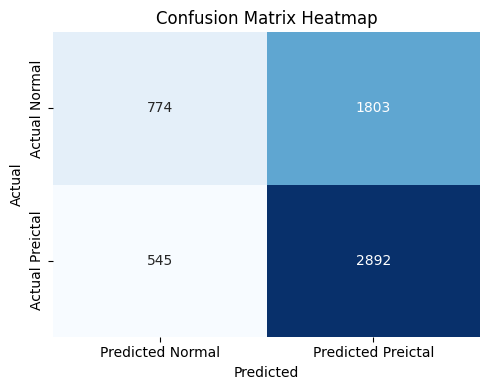

In [21]:
# Compute confusion matrix
cm = confusion_matrix(act, preds)

# Create heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
            xticklabels=['Predicted Normal', 'Predicted Preictal'],
            yticklabels=['Actual Normal', 'Actual Preictal'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()